# Jan_9th_Advertising_Linear Regression 

In [ ]:
#Problem statement:- To find the effect of different type of Advertisement on Sales  

In [3]:
# import the basic library
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [4]:
os.getcwd()

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Linear Regression\\Advertising Linear Regression'

In [5]:
df=pd.read_csv("Advertising.csv")#reading dataset

In [6]:
df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,450.0,17.5,69.2,22.1
1,2,44.5,18.5,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,NaN,18.9,58.5,18.5
4,5,180.8,15.8,58.4,12.9


In [ ]:
# It seems to be a Regression Problem as the Dependent Variable SALES is a contineous data.

In [7]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,197.000000,197.000000,200.000000,200.000000
mean,100.500000,149.696954,22.993401,30.750000,14.022500
std,57.879185,90.235859,14.665662,22.179668,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,73.400000,10.100000,12.750000,10.375000
50%,100.500000,149.800000,21.700000,25.750000,12.900000
75%,150.250000,220.300000,35.600000,45.100000,17.400000
max,200.000000,450.000000,49.600000,114.000000,27.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          197 non-null    float64
 2   Radio       197 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [8]:
df.shape

(200, 5)

In [8]:
# Drop the insignificant column

In [9]:
df1=df.drop(["Unnamed: 0"],axis=1)

In [10]:
df1.head()

,TV,Radio,Newspaper,Sales
0,450.0,17.5,69.2,22.1
1,44.5,18.5,45.1,10.4
2,17.2,45.9,69.3,9.3
3,NaN,18.9,58.5,18.5
4,180.8,15.8,58.4,12.9


In [11]:
# to find the information of dataset
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         197 non-null    float64
 1   Radio      197 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [12]:
# all are numeric values float type



In [ ]:
#To check the normal distribution status of data.

In [12]:
df1.skew()

TV           0.143365
Radio        0.137004
Newspaper    0.937312
Sales        0.407571
dtype: float64

In [14]:
df1.kurtosis()

TV          -0.618442
Radio       -1.183558
Newspaper    0.715567
Sales       -0.408869
dtype: float64

In [ ]:
# skewness and kurtosis range -3 to +3 , it as APPROXIMATELY normally distributed.

In [15]:
# DATA PROCESSING STEP
#(1) MISSING DATA 

In [15]:
#calculate the percentage of missing value 
df1.isnull().sum()/len(df1)*100

TV           1.5
Radio        1.5
Newspaper    0.0
Sales        0.0
dtype: float64

In [16]:
df1.isnull().sum()

TV           3
Radio        3
Newspaper    0
Sales        0
dtype: int64

In [18]:
#there is missing value in TV and Radio Column

In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         197 non-null    float64
 1   Radio      197 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [22]:
#df.dropna(inplace=True)  # will drop all rows with NaN in any column, but this approach is not good.

In [23]:
# checking outlier , outlier is very significant part in REGRESSION model.

<AxesSubplot:>

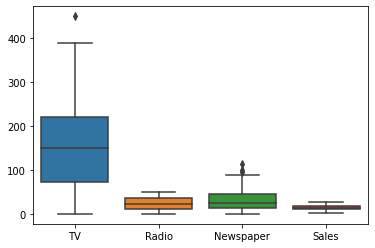

In [18]:
sns.boxplot(data=df1)

In [19]:
# handling missing value :- mean, mode, median approach

In [20]:
df1["TV"]=df1["TV"].fillna(df1["TV"].median())## Median approach because it has outliers

In [21]:
df1["Radio"]=df1["Radio"].fillna(df1["Radio"].mean())## Mean approach

<AxesSubplot:>

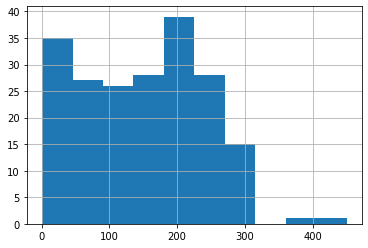

In [22]:
df1['TV'].hist()

array([[<AxesSubplot:title={'center':'TV'}>,
        <AxesSubplot:title={'center':'Radio'}>],
       [<AxesSubplot:title={'center':'Newspaper'}>,
        <AxesSubplot:title={'center':'Sales'}>]], dtype=object)

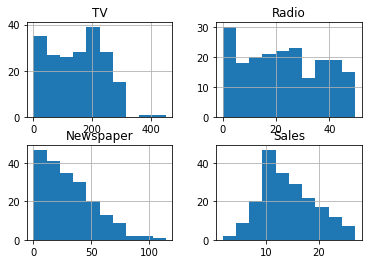

In [23]:
df1.hist()

<AxesSubplot:title={'center':'Original Data: NOT Much linear'}, ylabel='Density'>

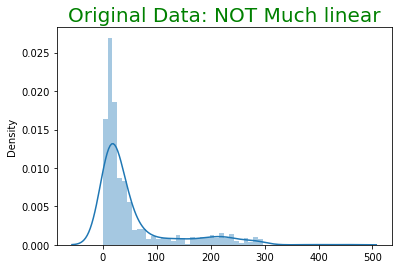

In [24]:
import matplotlib.pyplot as plt
plt.title(label="Original Data: NOT Much linear",
          fontsize=20,
          color="green")
  
import seaborn as sns
sns.distplot((df1))

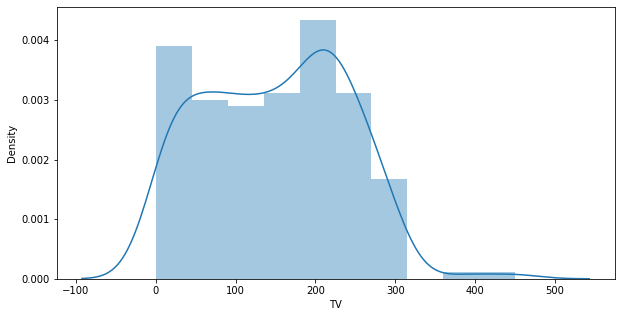

In [25]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['TV'])
plt.show()

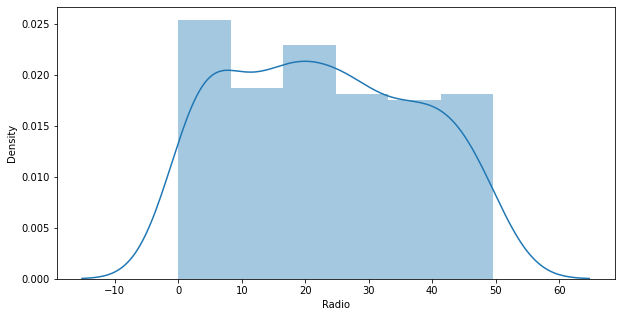

In [26]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Radio'])
plt.show()

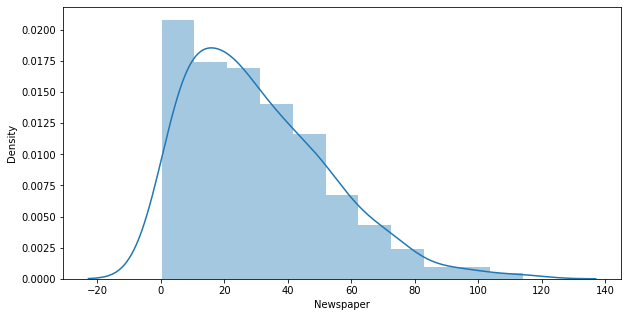

In [23]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Newspaper'])
plt.show()

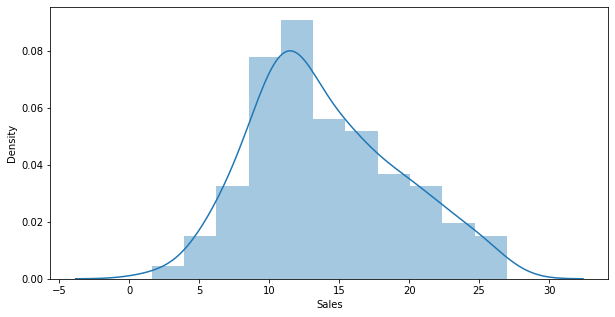

In [27]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Sales'])
plt.show()

In [28]:
#create cbrt-transformed data
df1 = np.cbrt(df1)

<AxesSubplot:title={'center':'Original Data: NOT Much linear'}, ylabel='Density'>

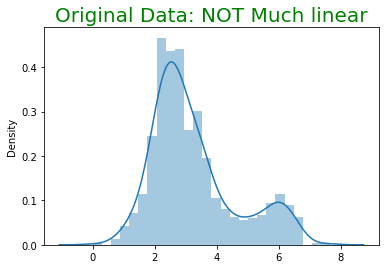

In [29]:
import matplotlib.pyplot as plt
plt.title(label="Original Data: NOT Much linear",
          fontsize=20,
          color="green")
  
import seaborn as sns
sns.distplot((df1))

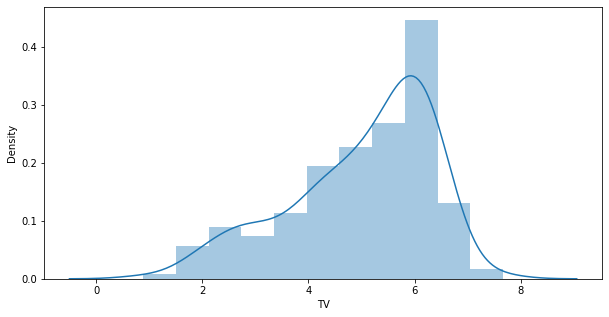

In [30]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['TV'])
plt.show()

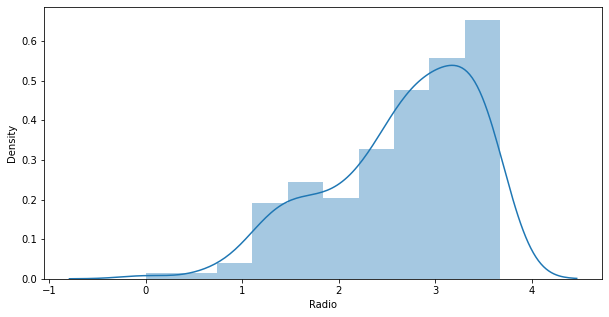

In [31]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Radio'])
plt.show()

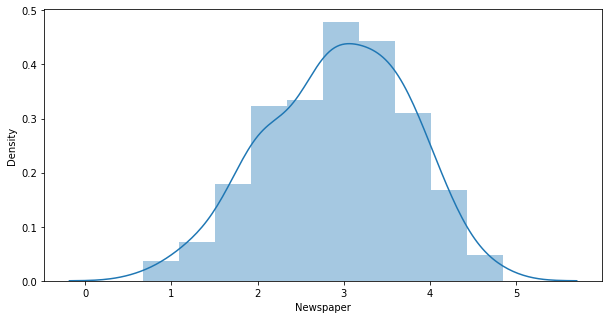

In [32]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Newspaper'])
plt.show()

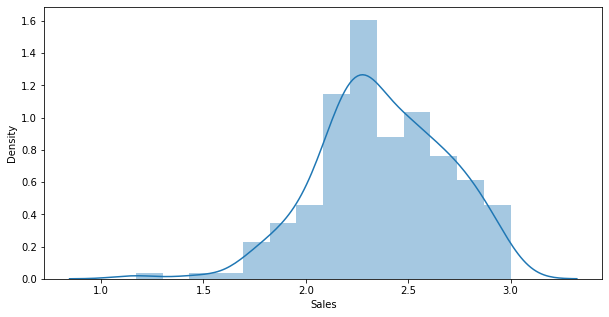

In [33]:
plt.figure(figsize=(10,5))
#plt.subplot(1,2,1)
sns.distplot(df1['Sales'])
plt.show()

In [ ]:
# checking the skewness and kurtosis

In [99]:
df1.skew()

TV          -0.770850
Radio       -0.705187
Newspaper   -0.239632
Sales       -0.326555
dtype: float64

In [100]:
df1.kurtosis()

TV          -0.255352
Radio       -0.364636
Newspaper   -0.416648
Sales        0.429271
dtype: float64

In [ ]:
# looking for outliers

<AxesSubplot:ylabel='TV'>

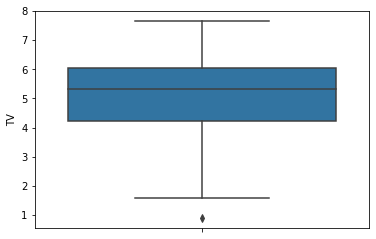

In [34]:
sns.boxplot(y="TV", data=df1)

<AxesSubplot:ylabel='Radio'>

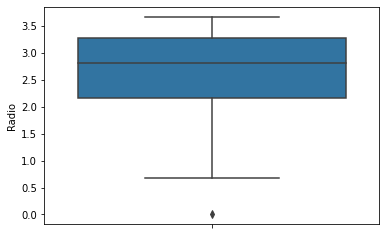

In [35]:
sns.boxplot(y="Radio", data=df1)

<AxesSubplot:ylabel='Newspaper'>

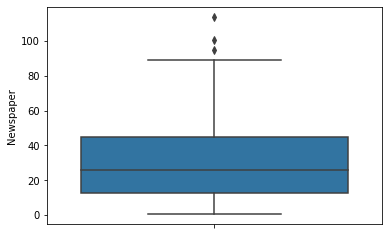

In [36]:
sns.boxplot(y="Newspaper", data=df)

In [37]:
# Handling outliers

In [38]:
#  FINDING IQR, Upper limit, Lower Limit

In [37]:

# here it is necessary to apply it on targeted colums , we will use numpy .

Q1_TV=df1["TV"].quantile(0.25)
print
Q3_TV=df1["TV"].quantile(0.75)
IQR_TV=Q3_TV-Q1_TV
upper_limit_TV=(Q3_TV+1.5*IQR_TV)
print("upper_limit_TV",upper_limit_TV)
lower_limit_TV=(Q1_TV-1.5*IQR_TV)
print("lower_limit_TV",lower_limit_TV)

upper_limit_TV 8.77378408536194
lower_limit_TV 1.4733572124672967


In [38]:
Q3_TV

6.036124008026449

In [39]:
# here it is necessary to apply it on targeted colums , we will use numpy .

Q1_Newspaper=df1["Newspaper"].quantile(0.25)
print
Q3_Newspaper=df1["Newspaper"].quantile(0.75)
IQR_Newspaper=Q3_Newspaper-Q1_Newspaper
upper_limit_Newspaper=(Q3_Newspaper+1.5*IQR_Newspaper)
print("upper_limit_Newspaper",upper_limit_Newspaper)
lower_limit_Newspaper=(Q1_Newspaper-1.5*IQR_Newspaper)
print("lower_limit_Newspaper",lower_limit_Newspaper)

upper_limit_Newspaper 5.394586723866761
lower_limit_Newspaper 0.5010917029445197


In [40]:
Q1_Newspaper

2.33615233579036

In [41]:
Q1_Radio=df1["Radio"].quantile(0.25)
print
Q3_Radio=df1["Radio"].quantile(0.75)
IQR_Radio=Q3_Radio-Q1_Radio
upper_limit_Radio=(Q3_Radio+1.5*IQR_Radio)
print("upper_limit_Radio",upper_limit_Radio)
lower_limit_Radio=(Q1_Radio-1.5*IQR_Radio)
print("lower_limit_Radio",lower_limit_Radio)

upper_limit_Radio 4.95422321089955
lower_limit_Radio 0.5030235433388477


In [42]:
Q1_Radio

2.172223418674111

In [43]:
df1['TV']=np.where(df1['TV']>upper_limit_TV,upper_limit_TV,np.where(df1['TV']<lower_limit_TV,lower_limit_TV,df1['TV']))

In [44]:
df1['Newspaper']=np.where(df1['Newspaper']>upper_limit_Newspaper,upper_limit_Newspaper,np.where(df1['Newspaper']<lower_limit_Newspaper,lower_limit_Newspaper,df1['Newspaper']))

In [45]:
df1['Radio']=np.where(df1['Radio']>upper_limit_Radio,upper_limit_Radio,np.where(df1['Radio']<lower_limit_Radio,lower_limit_Radio,df1['Radio']))

In [46]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


<AxesSubplot:>

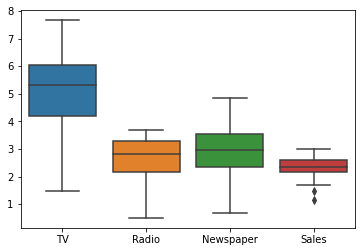

In [47]:
sns.boxplot(data=df1)

In [50]:
# pre processing part 4 :- 

In [51]:
#EDA-Exploratory Data Analysis
#(1)Multivariates Analysis


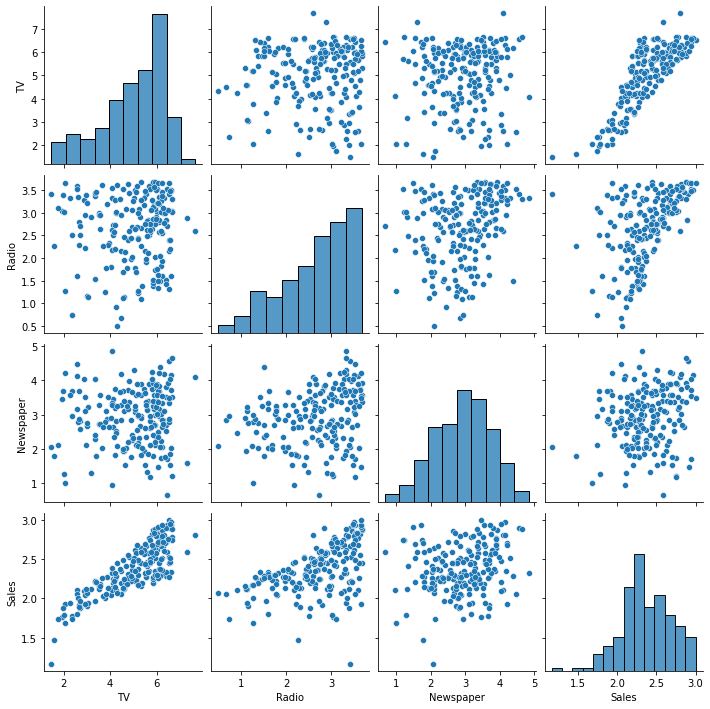

In [48]:
sns.pairplot(df1)

In [49]:
df1.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.043348,0.047251,0.829945
Radio,0.043348,1.000000,0.255902,0.500146
Newspaper,0.047251,0.255902,1.000000,0.195330
Sales,0.829945,0.500146,0.195330,1.000000


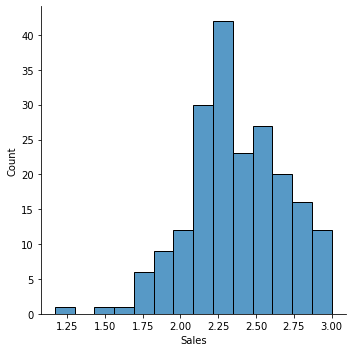

In [50]:
# Univariate  on dependent variable price

sns.displot(df1["Sales"])

In [51]:
df1.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.043348,0.047251,0.829945
Radio,0.043348,1.000000,0.255902,0.500146
Newspaper,0.047251,0.255902,1.000000,0.195330
Sales,0.829945,0.500146,0.195330,1.000000


<AxesSubplot:>

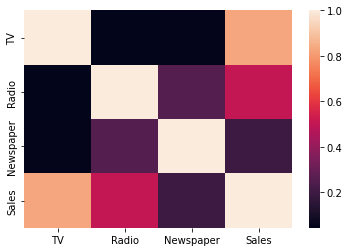

In [52]:
# if there are any two values are same , it is called Multi collinearity. than we can drop any of that equal Ind Variable.
#Same data we can plot in heatmap for more better understanding.

sns.heatmap(df1.corr())

<AxesSubplot:>

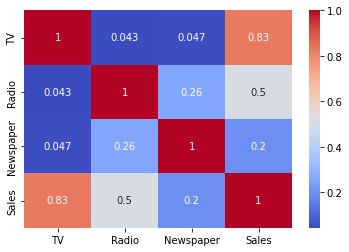

In [53]:
sns.heatmap(df1.corr(), annot=True,cmap="coolwarm")

# splitting the data into dependent and independent variable
